In [ ]:
import numpy as np
import pandas as pd
d=pd.read_csv("/content/drive/MyDrive/MLT 717824I342/Titanic-Dataset.csv")


In [ ]:
d.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
d.tail()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


In [ ]:
d.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [ ]:
d.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [ ]:
d.shape

(891, 12)

In [ ]:
from sklearn.impute import SimpleImputer
im=SimpleImputer(strategy='most_frequent')
d[['Age']]=im.fit_transform(d[['Age']])
from sklearn.impute import SimpleImputer
im=SimpleImputer(strategy='most_frequent')
d[['Age']]=im.fit_transform(d[['Cabin']])

In [ ]:
d=d.drop('Cabin',axis=1)

In [ ]:
#Categorical encoding
from sklearn.preprocessing import LabelEncoder
l=LabelEncoder()
d['Sex']=l.fit_transform(d['Sex'])
d['Embarked']=l.fit_transform(d['Embarked'])
d['Age']=l.fit_transform(d['Age'])
d['Ticket']=l.fit_transform(d['Ticket'])
d

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",1,47,1,0,523,7.2500,2
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,81,1,0,596,71.2833,0
2,3,1,3,"Heikkinen, Miss. Laina",0,47,0,0,669,7.9250,2
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,55,1,0,49,53.1000,2
4,5,0,3,"Allen, Mr. William Henry",1,47,0,0,472,8.0500,2
...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",1,47,0,0,101,13.0000,2
887,888,1,1,"Graham, Miss. Margaret Edith",0,30,0,0,14,30.0000,2
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",0,47,1,2,675,23.4500,2
889,890,1,1,"Behr, Mr. Karl Howell",1,60,0,0,8,30.0000,0


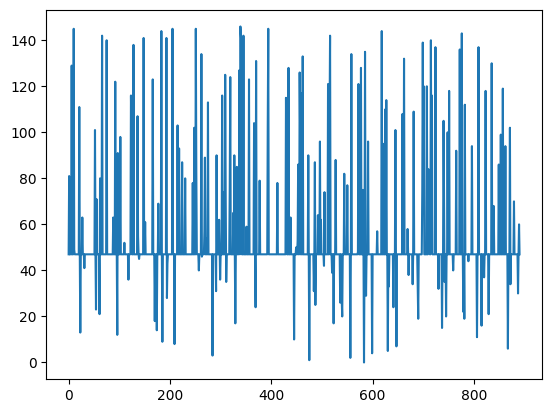

In [ ]:
import matplotlib.pyplot as plt
b=d["Age"]
plt.plot(b)

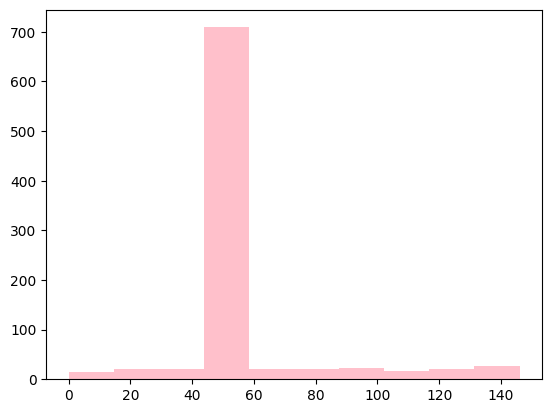

In [ ]:
plt.hist(b,color='pink')
plt.show()

In [ ]:
x=d[['SibSp','Parch']]
y=d[["Survived"]]

In [ ]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
clf=KNeighborsClassifier()
clf.fit(x_train,y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/neighbors/_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


KNeighborsClassifier()

In [ ]:
#predicting
y_predict=clf.predict(x_test)

          SibSp     Parch
SibSp  1.000000  0.414838
Parch  0.414838  1.000000


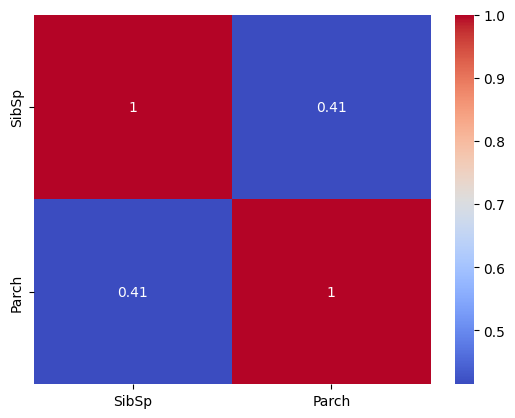

In [ ]:
#Heatmap
import seaborn as sns
correlation_matrix=x.corr()
print(correlation_matrix)
sns.heatmap(correlation_matrix,cmap='coolwarm',annot=True)
plt.show()

In [ ]:
#Evaluatin metrics
from sklearn.metrics import accuracy_score
print("Accuracy score: ",accuracy_score(y_test,y_predict))

Accuracy score:  0.6815642458100558


In [ ]:
from sklearn.metrics import confusion_matrix
cm=confusion_matrix(y_test,y_predict)
print(cm)

[[87 18]
 [39 35]]


In [ ]:
from sklearn.metrics import classification_report
cr=classification_report(y_test,y_predict)
print(cr)

              precision    recall  f1-score   support

           0       0.69      0.83      0.75       105
           1       0.66      0.47      0.55        74

    accuracy                           0.68       179
   macro avg       0.68      0.65      0.65       179
weighted avg       0.68      0.68      0.67       179

